In [6]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cooler
import bioframe
import cooler as clr
import h5py
import coolbox
from coolbox.api import *
from coolbox.utilities import GenomeRange
from coolbox import coolbox_helpers

from pygenometracks import readBed, readGtf
from pygenometracks.tracks import BedTrack

import glob
from pathlib import Path
warnings.filterwarnings("ignore")

import re
import cooltools
from cooltools.lib import plotting

import logging
logging.getLogger('matplotlib.font_manager').disabled = True
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams["font.size"] = 12
plt.rcParams.update({
    "text.usetex": False})
plt.rc('pdf',fonttype = 42)


In [90]:
def make_region_plot_mod(region, resolution, microc_file,
                     bw_list, condition_order, gene_annot_name,file_bottom=None,
                    bedgraph_fname=None, plot_variants=False, variant_track_height=2, 
                    plot_bed=False,cmap_chip='tab10',
                    plot_genes=True, **kwargs):
    
    """
    Function that makes a plot of a region with Micro-C, ChIP-seq, and other tracks.
    
    region: (str) string that specifies region for plotting.
    resolution: (int) resolution of micro-c map used
    highlight_region_list: List of regions of format [chr, start, end] to highlight
    microc_file: (str) file path to micro-c data
    microc_title: (str) title for micro-c
    bw_list: List of lists, or simple list. If list of list and autoscale, values are autoscaled within each list. 
            If simple list and autoscale, values are individually autoscaled.
    condition_order: List indicating order of conditions to plot. 
    """
    
    print(region, resolution, microc_file)
    heatmap = Cool(microc_file, file_bottom=file_bottom, resolution=resolution, **MICROC_PLOTTING_PARAMS) 
    frame = heatmap + Spacer(SPACER_HEIGHT*3)
    
    if plot_bed:
        frame+=NewBed(*BED_PARAMS) + TrackHeight(BED_PARAMS[0].get('height', 1)) + Spacer(SPACER_HEIGHT) 
  
    custom_maxes = kwargs.get('custom_maxes', [None]*len(bw_list))
    
    assert len(custom_maxes)==len(bw_list), "If not autoscaling, all max values must be set"
    cmap_arr = sns.color_palette(cmap_chip, n_colors=len(bw_list))
    
    # if input bigwigs are a list of lists, plot each set 
    if coolbox_helpers.is_nested(bw_list):
        for i, (ymax, bigwig_set, order) in enumerate(zip(custom_maxes, bw_list, condition_order)):
            print(ymax)
            bigwig_set_plot = coolbox_helpers.make_bigwig_list(bigwig_set, region, order, autoscale=True,
                                                               y_max=ymax,
                                               **BIGWIG_PARAMS)
            for bigwig in bigwig_set_plot:
                frame += bigwig + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)
    
    # if input bigwigs are a simple list, plot each
    else:
        bigwig_set_plot = coolbox_helpers.make_bigwig_list(bw_list, region, condition_order, autoscale=False,  **BIGWIG_PARAMS)
        for i, (ymax, bigwig) in enumerate(zip(custom_maxes, bigwig_set_plot)):
            bigwig = coolbox_helpers.auto_scale_bigwig(bigwig, region, y_max=ymax)
            frame += bigwig + Color(cmap_arr[i])+ Spacer(SPACER_HEIGHT)
    
    if plot_genes:
        annotations = NewBed(*GTF_PARAMS)

    frame+=annotations
    return frame


In [8]:
class NewBed(Track):
    """
    Custom pygenometracks class that allows for control over the aesthetics of gene annotations in
    region plots.
    """

    def __init__(self, coolbox_prop_dict, pygenometracks_prop_dict):
        super().__init__(coolbox_prop_dict)  # init
        self.pygenometracks_object = BedTrack(pygenometracks_prop_dict)

    def fetch_data(self, gr, **kwargs):
        pass

    def plot(self, ax, gr, **kwargs):
        self.pygenometracks_object.plot(ax, gr.chrom, gr.start, gr.end)
        ax.set_xlim([gr.start, gr.end])


In [10]:
base_dir = '/mnt/coldstorage/Varshmallow/'


resolution = 2000
phases_microc = {1: 'Phase1_', 2:'Phase2_dedup',3:'Phase3_dedup'}

phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_filenames = [os.path.join(uc_path, f"Sankaran_{p}merged.250.mcool") for p in phases]

In [27]:
os.listdir(base_dir)

['varshinishares',
 'Blood_ChIP_BDG',
 'Blood_ATAC',
 'Adipose_Blood_Merged',
 'move_to_shares.sh',
 'mover3.out',
 'RCMC_Adipose_PanelMerge_AllReps_D0_allCap_hg38.merged.50.mcool',
 'RCMC_Adipose_PanelMerge_AllReps_D14_allCap_hg38.merged.50.mcool',
 'Adipose_RCMC',
 'Adipose_CTCF',
 'mover.out',
 'Blood_RCMC',
 'Blood_RNAseq',
 'nohup.out',
 'Blood_ChIP',
 'D1_P123_Rep1_ATAC.bam.bai',
 'mover4.out',
 'hg38',
 'Adipose_H3K27ac',
 'Mitosis_Data',
 'sim_outputs',
 'RCMC_Adipose_PanelMerge_AllReps_D3_allCap_hg38.merged.50.mcool',
 'Adipose_ATAC',
 'Adipose_Blood_Genomics',
 'References',
 'mover2.out',
 'Adipose_Histone',
 'varsh.txt',
 'hg38_analysisSet',
 'Adipose_RNAseq',
 'misc_cleo',
 'Adipose_Haplotyping',
 'Blood_Test_Data',
 'mover5.out',
 'test.gz',
 'Blood_GWAS']

In [78]:
ctcf_stranded_bed = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/merged_CTCF_P123_strand.bed'
gtf_filename = "/mnt/md0/varshini/Gene_Annotations/refSeqSelect.bed"

In [92]:
MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-0.5,
                          "min_value":-4.5}

BED_PARAMS = [{"height":1},
                      {"file": ctcf_stranded_bed,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]


SPACER_HEIGHT = 0.4

BIGWIG_PARAMS = {
    "bw_bins":1600,
    "track_height":1,
}

regions = {
        'BCL11A':'chr2:59964475-60946280',
        'BCL11A_loop':'chr2:60474501-60570501',
        'BCL11A_full':'chr2:58464475-60946280',
        'loop_appear': 'chr5:173570169-174026097 ',
        'loop_disappear': 'chr7:11365292-12545212',
        'boundary_appear_2': 'chr14:101120681-104109207',
        'boundary_disappear': 'chr8:75561811-79081548',
        'compt_ex1': 'chr5:149023111-152003168',
        'compt_ex2': 'chr1:48000000-102000000',
}


GTF_PARAMS = [
     {"height":2},
    {"file":gtf_filename,
     "max_labels":1000,
    #"gene_rows":3,
    "merge_transcripts":True,    
    "border_only":"true",
     "color":"#000000"
    }] 



In [93]:
incl= ['RNASeq_P1','RNASeq_P3','ATAC_P1', 'ATAC_P3']
 
chip_list = [f'{base_dir}Blood_RNAseq/Phase1_RNA_chr.bw',
             f'{base_dir}Blood_RNAseq/Phase3_RNA_chr.bw',
            f'{base_dir}Blood_ATAC/Phase1_ATAC.bw',
            f'{base_dir}Blood_ATAC/Phase3_ATAC.bw']


chr17:44081815-44481815 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|███████████████████████████████| 22438/22438 [00:00<00:00, 25688.84it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(3.38), np.float64(-0.08))
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(10.28), np.float64(-0.08))


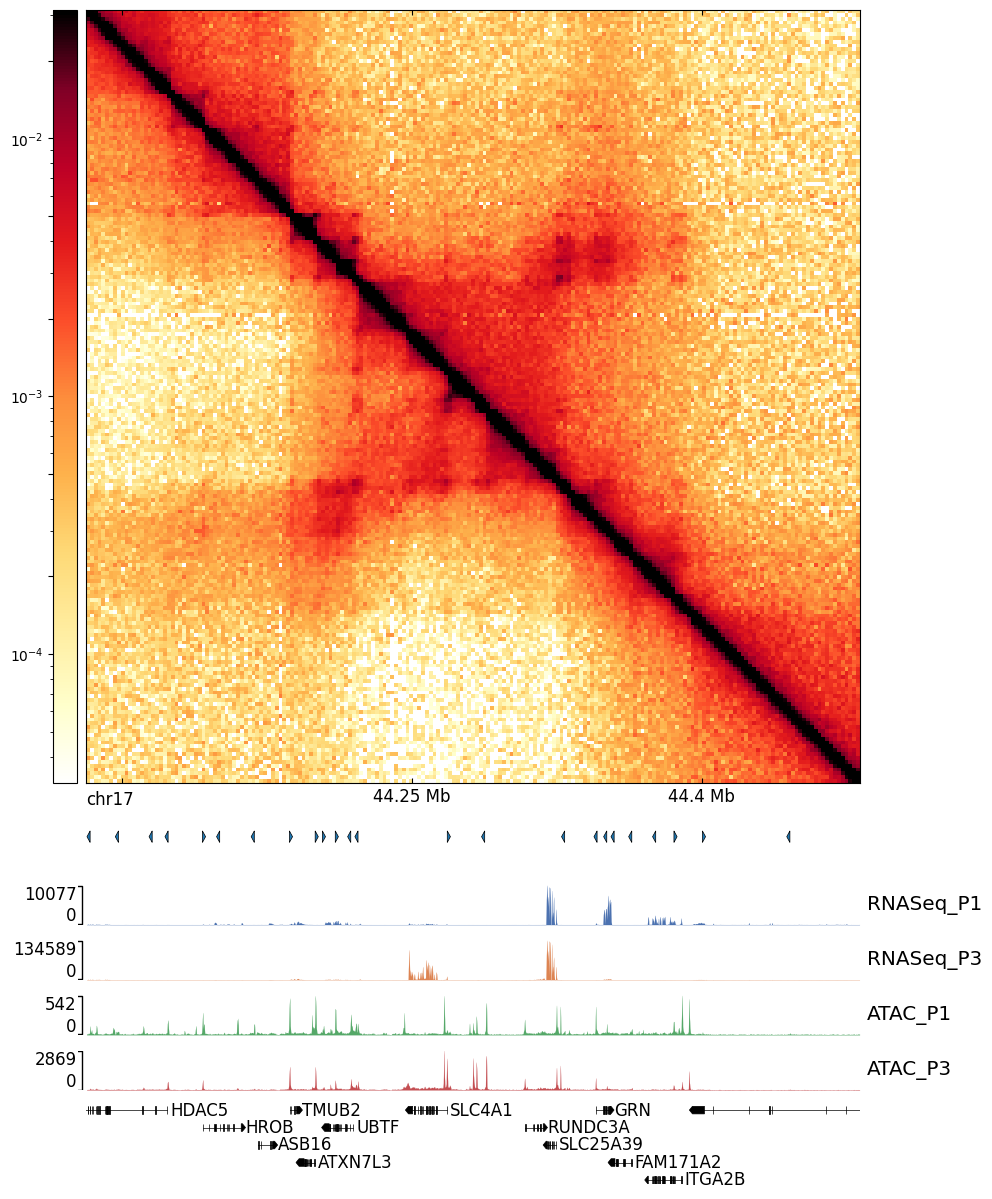

In [94]:
# example of scaling everything 

region_str = 'chr17:44081815-44481815'
resolution=2000

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":None,
                          "norm":"log",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":10**-1.5,
                          "min_value":10**-4.5,
                          "fontsize":12,
                          "cbar_fraction":4,
                          "cbar_aspect":32,
                           "plot_axis":True,
                          "tick_spacing_bp":150_000
                         }


frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         bw_list=chip_list, condition_order=incl, gene_annot_name=gtf_filename,
                         file_bottom = uc_filenames[2], cmap_chip="deep", 
                        plot_genes=True, plot_bed=True)

frame.properties["width"] = 24
fig = frame.plot(region_str)
fig


In [95]:
## you can make nested lists any way you like, this was just convenient for me
nesting = [0, 0, 1, 1]

chip_nested = [[x for x, n in zip(chip_list, nesting) if n == group] for group in sorted(set(nesting))]
order_nested = [[x for x, n in zip(incl, nesting) if n == group] for group in sorted(set(nesting))]


In [96]:
chip_nested

[['/mnt/coldstorage/Varshmallow/Blood_RNAseq/Phase1_RNA_chr.bw',
  '/mnt/coldstorage/Varshmallow/Blood_RNAseq/Phase3_RNA_chr.bw'],
 ['/mnt/coldstorage/Varshmallow/Blood_ATAC/Phase1_ATAC.bw',
  '/mnt/coldstorage/Varshmallow/Blood_ATAC/Phase3_ATAC.bw']]

chr17:44081815-44481815 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool
None
None


100%|███████████████████████████████| 22438/22438 [00:00<00:00, 26003.50it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(10.28), np.float64(-0.08))


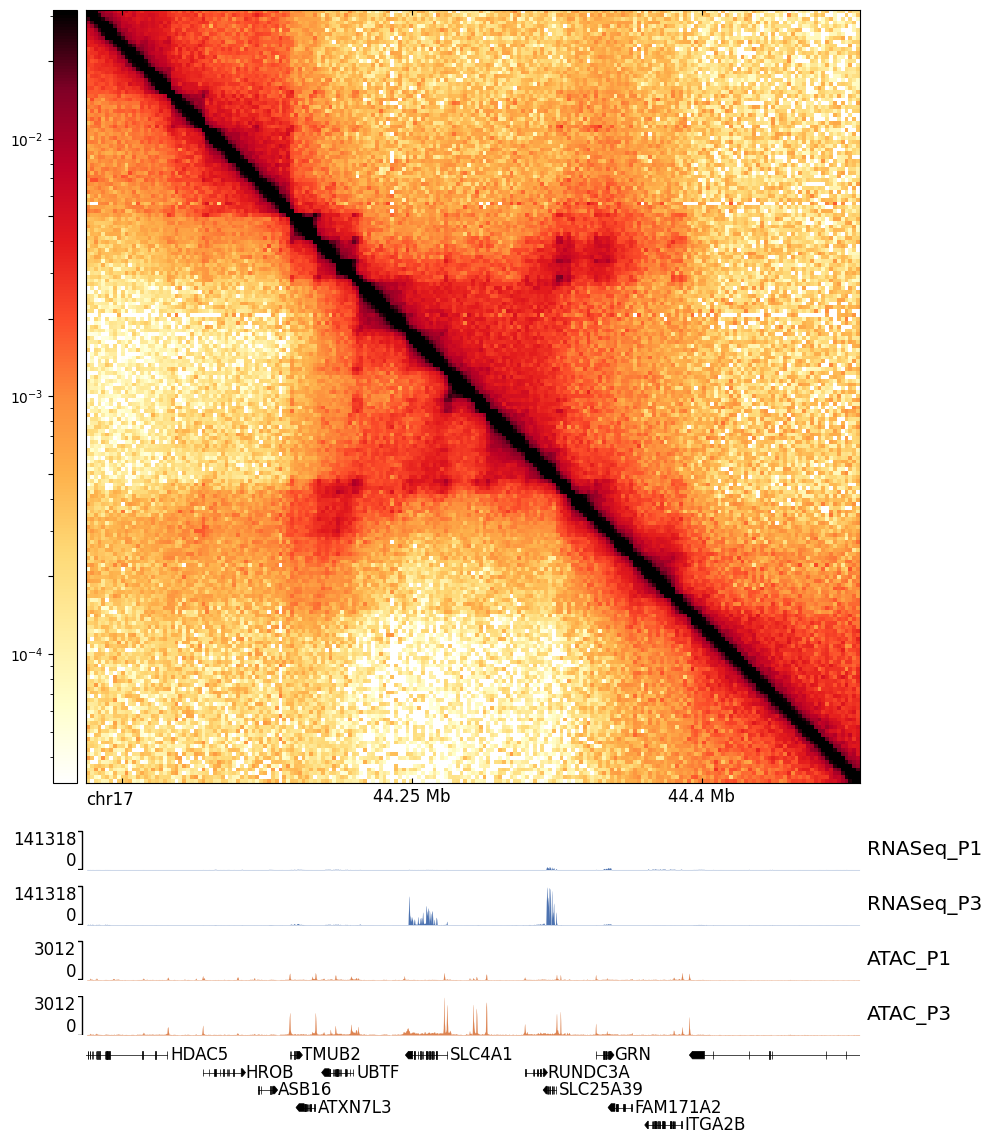

In [97]:
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         bw_list=chip_nested, condition_order=order_nested, gene_annot_name=gtf_filename,
                         file_bottom = uc_filenames[2], cmap_chip="deep", 
                        plot_genes=True, plot_bed=False)

frame.properties["width"] = 24
fig = frame.plot(region_str)
fig
fig

chr17:44081815-44481815 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool
140000
3000


100%|███████████████████████████████| 22438/22438 [00:00<00:00, 26103.98it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(10.28), np.float64(-0.08))


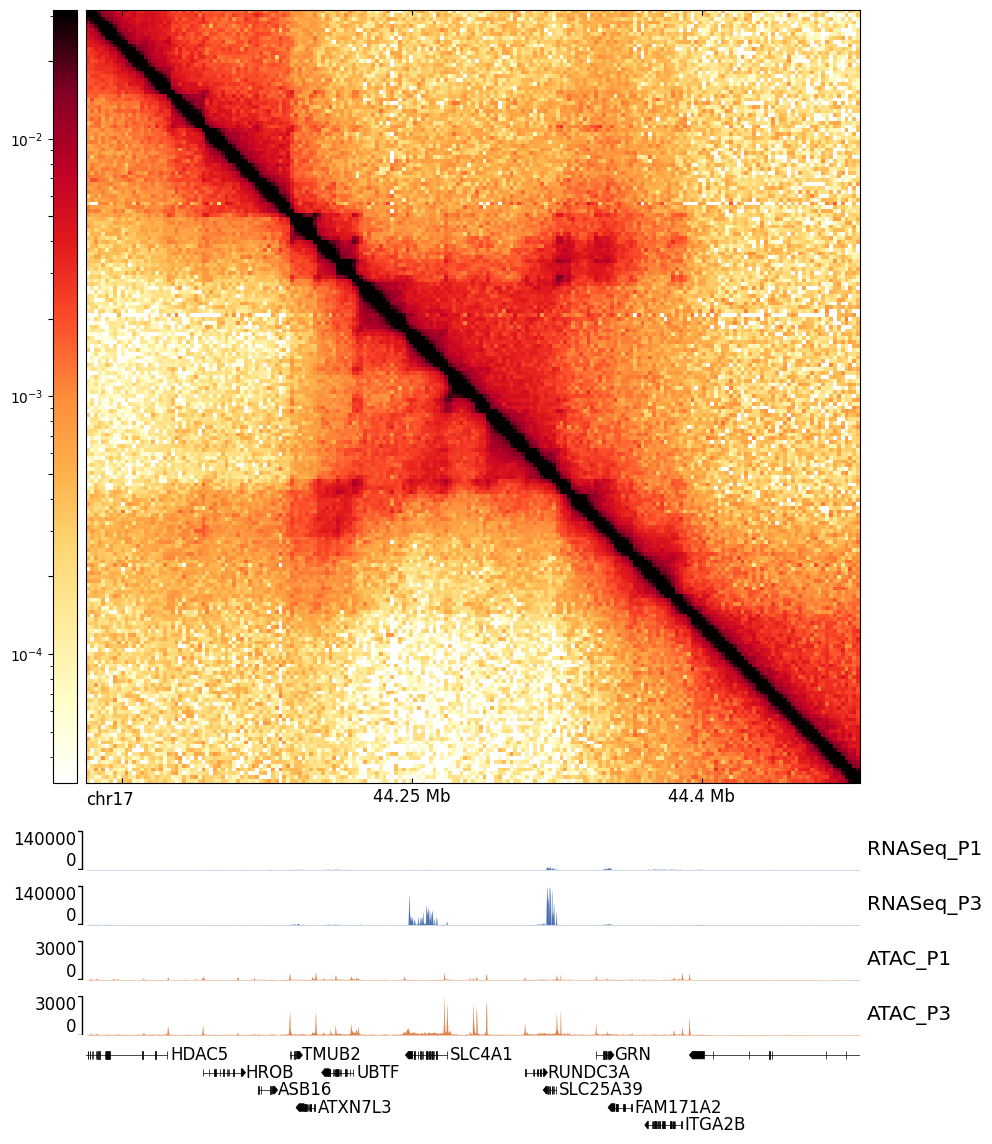

In [98]:
## now, i want to auto-set values

frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         bw_list=chip_nested, condition_order=order_nested, gene_annot_name=gtf_filename,
                         file_bottom = uc_filenames[2], cmap_chip="deep", 
                        plot_genes=True, custom_maxes=(140_000, 3000))

frame.properties["width"] = 24
fig = frame.plot(region_str)
fig